In [1]:
from lib import epl 
from lib import OSN
from lib import readout
from lib import plots
import time
import numpy as np
import pickle 
import brian2 as b2
import brian2hears as b2h
import matplotlib.pyplot as plt
#import csv
import os.path
from os import path
%matplotlib inline
from preprocess import preprocessing as pre

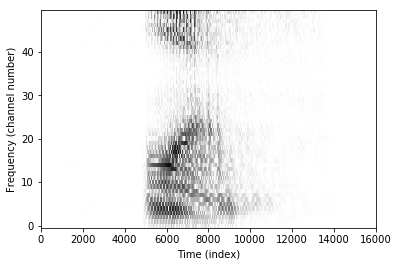

In [2]:
testSounds = ["0a196374_nohash_1","0a2b400e_nohash_0","0a2b400e_nohash_1","0a2b400e_nohash_2","0a2b400e_nohash_3","0a9f9af7_nohash_0","0a9f9af7_nohash_1","0a9f9af7_nohash_2","00f0204f_nohash_0","00f0204f_nohash_1"]
trainingSounds = ["0a196374_nohash_1"]
scale = 15  #changed because we're normalising in a different way
#I changed scale from 15 to 10 because 16 resulted in a KeyError: 21
# normalising 0 to 1, then multiply by scale (15)
# this is to scale each individual sample

trainingSpect = pre.spectArray(trainingSounds[0], cfN=50)

#pre.spectShow(trainingSpect[:,5000:7000]) #, zoom_x=5000, zoom_y=7000)
pre.spectShow(trainingSpect)
trainingIndex = [5500,6000]
range_f = 100
step_f = 10
#sample the odors
for sound in testSounds:
    for i in trainingIndex:
        if i == trainingIndex[0]:
            trainingOdors = pre.chooseSound(pre.spectArray(sound, cfN=50), range_f, step_f, i, scale);
        else:
            trainingOdors = np.concatenate((trainingOdors, pre.chooseSound(pre.spectArray(sound,cfN=50), range_f, step_f, i, scale)))
#trainingOdors = trainingOdors.tolist()
"""
trainingOdors = trainingSpect[:,trainingIndex[0]:trainingIndex[0]+range_f:step_f]
#flatten list (np function) above to 1 row and 110 samples
#trainingOdors = trainingOdors.flatten()
trainingOdors = trainingOdors.reshape((1,-1))
#scale the training samples
trainingOdors *= scale/trainingOdors.max()
trainingOdors = trainingOdors.astype(np.int64)
# function for training the network
"""
testOdors = np.array([])

indices_list = []
#training_spects = np.array()
for sound in testSounds:
    testingSpect = pre.spectArray(sound, cfN=50)
    #testingOdors.append(testingSpect[:,trainingIndex[0]:trainingIndex[0]+range_f:step_f])
    #testOdors = np.append([testOdors],[pre.chooseSound(testingSpect, range_f, step_f, trainingIndex[0], scale)])
    if testOdors.shape[0] == 0:
        testOdors = pre.chooseSound(testingSpect, range_f, step_f, trainingIndex[0],scale)
    else:
        testOdors = np.concatenate((testOdors,pre.chooseSound(testingSpect, range_f, step_f, trainingIndex[0],scale)))
    #indices_list.append()
#testOdors = np.insert([testOdors],[0]*500,[pre.chooseSound(testingSpect, range_f, step_f, trainingIndex[0], scale)])

#testOdors = testOdors.astype(np.int64)
#testOdors = testOdors.tolist()

In [3]:
from lib import epl 



#Network initialization
nMCs = len(trainingOdors[0]); 
GCsPerNeurogenesis = 5; 
nGCs = nMCs*GCsPerNeurogenesis*nOdors;     #every MC has 5 GCs per odor  
epl = epl.EPL(nMCs, nGCs, GCsPerNeurogenesis); 

#Sniff
def sniff(odor, learn_flag=0, nGammaPerOdor=5, gPeriod=40):
    sensorInput = OSN.OSN_encoding(odor); 
    for j in range(0, nGammaPerOdor):
        for k in range(0, gPeriod): 
            epl.update(sensorInput, learn_flag=learn_flag);
            pass; 
    epl.reset(); 

#Training
t1 = time.time(); 
for i in range(0, len(trainingOdors)):
    print("Training odor " + str(i+1)) 
    sniff(trainingOdors[i], learn_flag=1,nGammaPerOdor = 10); 
    # changed nGammaPerOdor from 5 to 10
    epl.GClayer.invokeNeurogenesis();
    sniff(trainingOdors[i], learn_flag=0);

#Testing
for i in range(0, len(testOdors)):
    sniff(testOdors[i], learn_flag=0); 
    if(i%10==0 and i!=0):
        print(str(i) + " odors tested"); 
t2 = time.time(); 
print("Simulation Duration = " + str(t2-t1) + "s")

#Readout
# has summary of a lot of the results
# find structure of sMatrix and summarize the performance for a particular run

sMatrix = readout.readout(epl.gammaCode, nOdors, nTestPerOdor)  
f=open('sMatrix.txt','a',fmt='%i',delimiter=', ')
np.savetxt(f,sMatrix)
f.close()
#Plots
plots.plotFigure4a(epl.gammaCode); 
"""
plt.savefig('fig4a:testOdorList3.png')  #SAVING FIGURES to png files
plots.plotFigure4b(sMatrix); 
plt.savefig('fig4b:testOdorList3.png')
"""
plots.plotFigure4d(epl.gammaCode, sMatrix); 


NameError: name 'nOdors' is not defined